In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh, inv
from scipy.linalg import pinv
from numba import njit
import numpy as np

# Linear Simulation

In [2]:
def compute_covariance(X0):
    return np.cov(X0, rowvar=False)

from scipy.stats import pearsonr, spearmanr
import numpy as np

def compute_pearson_correlation_matrix(X):
    """
    Compute pairwise Pearson correlation coefficients between columns of X.

    Parameters:
        X (ndarray): shape (n_samples, n_features)

    Returns:
        corr_matrix (ndarray): shape (n_features, n_features)
    """
    n_features = X.shape[1]
    corr_matrix = np.zeros((n_features, n_features))

    for i in range(n_features):
        for j in range(n_features):
            if i == j:
                corr_matrix[i, j] = 1.0
            else:
                corr, _ = pearsonr(X[:, i], X[:, j])
                corr_matrix[i, j] = corr

    return corr_matrix


In [3]:
def compute_gene_difference_covariance(x1_all, x2_all, time_index, twin=True):
    """
    Computes the covariance matrix of gene-wise differences between twin simulations
    (or between randomly paired cells if twin=False).

    Parameters
    ----------
    x1_all : ndarray, shape (n_cells, n_timepoints, n_genes)
        Simulation results for twin 1.
    x2_all : ndarray, shape (n_cells, n_timepoints, n_genes)
        Simulation results for twin 2.
    time_index : int
        Time point at which to compute differences.
    twin : bool, default=True
        If True, compares twins directly.
        If False, compares random pairs (shuffles x1 before differencing).

    Returns
    -------
    cov_matrix : ndarray, shape (n_genes, n_genes)
        Covariance matrix of gene-wise differences (x1 - x2).
    """
    # Get values at the given time point
    x1_t = x1_all[:, time_index, :]
    x2_t = x2_all[:, time_index, :]

    # Compute differences
    if not twin:
        x1_t = np.random.permutation(x1_t)  # shuffle x1 across cells

    diffs = x1_t - x2_t  # shape: (n_cells, n_genes)

    # Covariance of differences
    return compute_pearson_correlation_matrix(diffs)



In [ ]:
# Parameters
N = 2
T = 30
dt = 0.05
timesteps = int(T / dt)
lambda_base = 1.0
D = 0.5
epsilon = 1/(N)**.5*(1.-.05)  # subcritical but close to transition
# epsilon = 1/(N)**.5  # subcritical but close to transition
# epsilon = 1/(N)**.5*(1.+.05)  # subcritical but close to transition
np.random.seed(42)
K = np.random.normal(0, 1.0, size=(N, N)) - 1
# K = np.zeros(shape=(N, N))
# K = (K + K.T) / 2  # symmetrize
np.fill_diagonal(K, 0)
A = lambda_base * np.eye(N) + epsilon * K

# Compute the smallest real part of the eigenvalues of A
eigvals = np.linalg.eigvals(A)
lambda_min = np.min(np.real(eigvals))

# Estimate relaxation time
relax_time = 10 / lambda_min  # heuristic: ~5 relaxation times to reach steady state
# T = relax_time
# timesteps = int(T/dt)
print(f"Minimum eigenvalue of A (Re part): {lambda_min:.4f}")
print(f"Recommended minimum simulation time for relaxation: T ≳ {relax_time:.2f}")

@njit(fastmath=True)
def simulate_ou(A, u, with_input, timesteps, N, D, dt, x0=None):
    x = np.zeros((timesteps, N))
    
    # Set initial condition
    if x0 is not None:
        x[0] = x0

    sqrt_2Ddt = np.sqrt(2 * D * dt)
    zero_vec = np.zeros(N)
    force = u if with_input else zero_vec

    for t in range(1, timesteps):
        noise = np.random.normal(0.0, 1.0, N)
        dx = (-A @ x[t - 1] + force) * dt + sqrt_2Ddt * noise
        x[t] = x[t - 1] + dx

    return x


n_cells = 10000  # number of samples
samples = np.zeros((n_cells, N))

# Step 1: Draw initial states from some distribution (e.g., steady state OU)
for i in range(n_cells):
    x = simulate_ou(A, u, False, timesteps, N, D, dt)
    samples[i] = x[-1]  # Use final state as steady-state sample

# Step 2: Simulate twins starting from the same initial state
x1_all = np.zeros((n_cells, timesteps, N))
x2_all = np.zeros((n_cells, timesteps, N))

for i in range(n_cells):
    x0 = samples[i]
    x1_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)
    x2_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)

In [20]:
# Get values at time index 10 for all cells
x1_t10 = x1_all[:, 10, :]  # shape: (n_cells, N)
x2_t10 = x2_all[:, 10, :]  # shape: (n_cells, N)

# Concatenate x1_t10 and x2_t10 along the last axis
x_combined = np.concatenate((x1_t10, x2_t10), axis=0)  # shape: (n_cells, 2 * N)

cov = compute_covariance(x_combined)
cov

array([[0.67476923, 0.30718291],
       [0.30718291, 0.60442411]])

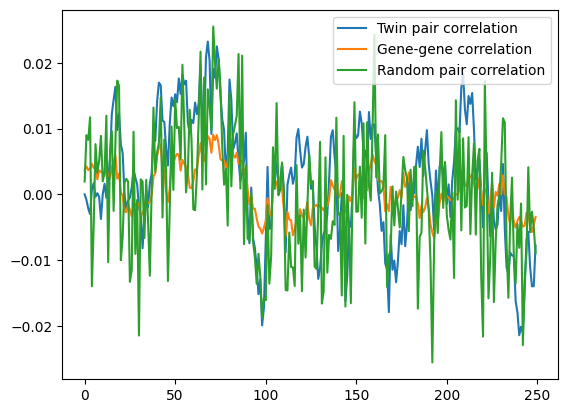

In [38]:
twin_pair_correlation = []
gene_gene_correlation = []
random_pair_correlation = []
time_points = np.arange(0, 30/0.05, 0.1/0.05)
for time in time_points:
    x1_at_time = x1_all[:, time, :]  # shape: (n_cells, N)
    x2_at_time = x2_all[:, time, :]  # shape: (n_cells, N)
    x_combined = np.concatenate((x1_at_time, x2_at_time), axis=0)  # shape: (n_cells, 2 * N)
    cov = compute_covariance(x_combined)[0, 1]
    gene_gene_correlation.append(cov)
    # Concatenate x1_t10 and x2_t10 along the last axis
    x_combined = np.concatenate((x1_t10, x2_t10), axis=0)  # shape: (n_cells, 2 * N)
    twin_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=True)[0, 1])
    random_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=False)[0, 1])

plt.plot(time_points, twin_pair_correlation, label = "Twin pair correlation")
plt.plot(time_points, gene_gene_correlation, label = "Gene-gene correlation")
plt.plot(time_points, random_pair_correlation, label = "Random pair correlation")
plt.legend()
plt.show()

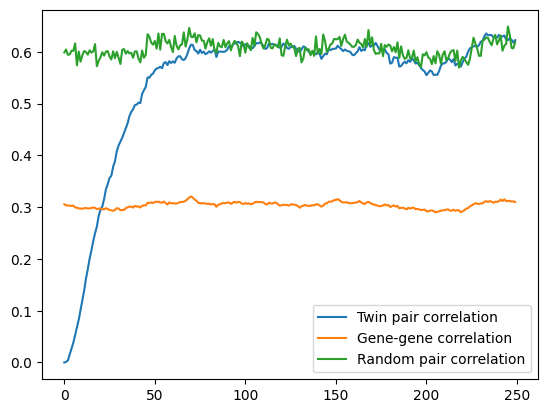

In [40]:
twin_pair_correlation = []
gene_gene_correlation = []
random_pair_correlation = []
time_points = np.arange(0, 250)
for time in time_points:
    x1_at_time = x1_all[:, time, :]  # shape: (n_cells, N)
    x2_at_time = x2_all[:, time, :]  # shape: (n_cells, N)
    x_combined = np.concatenate((x1_at_time, x2_at_time), axis=0)  # shape: (n_cells, 2 * N)
    cov = compute_covariance(x_combined)[0, 1]
    gene_gene_correlation.append(cov)
    # Concatenate x1_t10 and x2_t10 along the last axis
    x_combined = np.concatenate((x1_t10, x2_t10), axis=0)  # shape: (n_cells, 2 * N)
    twin_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=True)[0, 1])
    random_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=False)[0, 1])

plt.plot(time_points, twin_pair_correlation, label = "Twin pair correlation")
plt.plot(time_points, gene_gene_correlation, label = "Gene-gene correlation")
plt.plot(time_points, random_pair_correlation, label = "Random pair correlation")
plt.legend()
plt.show()

# Linear cascade of 3 genes


In [4]:
# Parameters
N = 3
T = 300
dt = 0.05
timesteps = int(T / dt)
lambda_base = 1.0
D = 0.05
# epsilon = 1/(N)**.5*(1.-.05)  # subcritical but close to transition
# # epsilon = 1/(N)**.5  # subcritical but close to transition
# # epsilon = 1/(N)**.5*(1.+.05)  # subcritical but close to transition
# np.random.seed(42)
# K = np.random.normal(0, 1.0, size=(N, N)) - 1
# # K = np.zeros(shape=(N, N))
# # K = (K + K.T) / 2  # symmetrize
# np.fill_diagonal(K, 0)
# A = lambda_base * np.eye(N) + epsilon * K
A = np.array([[1, -0.0, -0.0], [-5, 1, -0.0], [-0, -5.0, 1]])
# Compute the smallest real part of the eigenvalues of A
eigvals = np.linalg.eigvals(A)
lambda_min = np.min(np.real(eigvals))

# Estimate relaxation time
relax_time = 10 / lambda_min  # heuristic: ~5 relaxation times to reach steady state
# T = relax_time
# timesteps = int(T/dt)
print(f"Minimum eigenvalue of A (Re part): {lambda_min:.4f}")
print(f"Recommended minimum simulation time for relaxation: T ≳ {relax_time:.2f}")
u = np.zeros(N)
@njit(fastmath=True)
def simulate_ou(A, u, with_input, timesteps, N, D, dt, x0=None):
    x = np.zeros((timesteps, N))
    
    # Set initial condition
    if x0 is not None:
        x[0] = x0

    sqrt_2Ddt = np.sqrt(2 * D * dt)
    zero_vec = np.zeros(N)
    force = u if with_input else zero_vec

    for t in range(1, timesteps):
        noise = np.random.normal(0.0, 1.0, N)
        dx = (-A @ x[t - 1] + force) * dt + sqrt_2Ddt * noise
        x[t] = x[t - 1] + dx

    return x


n_cells = 10000  # number of samples
samples = np.ones((n_cells, N)) 

# Step 1: Draw initial states from some distribution (e.g., steady state OU)
for i in range(n_cells):
    x = simulate_ou(A, u, False, timesteps, N, D, dt)
    samples[i] = x[-1]  # Use final state as steady-state sample

# Step 2: Simulate twins starting from the same initial state
x1_all = np.zeros((n_cells, timesteps, N))
x2_all = np.zeros((n_cells, timesteps, N))

for i in range(n_cells):
    x0 = samples[i]
    x1_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)
    x2_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)

Minimum eigenvalue of A (Re part): 1.0000
Recommended minimum simulation time for relaxation: T ≳ 10.00


/home/mzo5929/.conda/envs/grnSimulationQuest/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


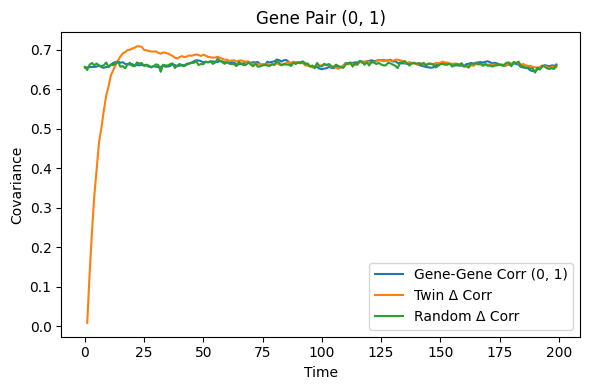

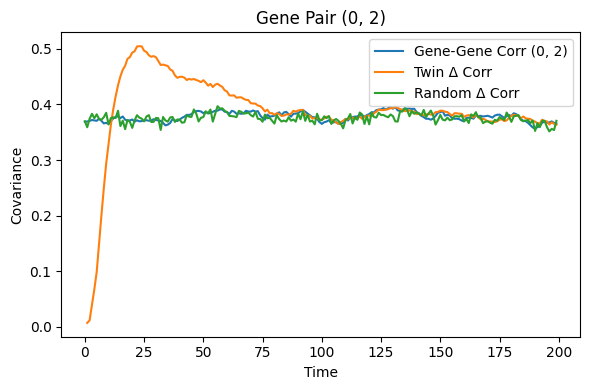

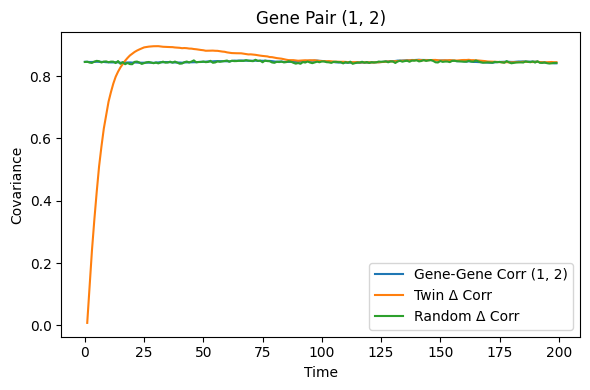

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations, permutations

# Initialize dictionary to store per-pair time series
twin_pair_correlation = {}
gene_gene_correlation = {}
random_pair_correlation = {}

n_genes = x1_all.shape[2]
time_points = np.arange(x1_all.shape[1])[:200:1]

# Initialize empty time series for each gene pair
gene_pairs = list(combinations(range(n_genes), 2))
for i, j in gene_pairs:
    twin_pair_correlation[(i, j)] = []
    gene_gene_correlation[(i, j)] = []
    random_pair_correlation[(i, j)] = []

for time in time_points:
    x1_at_time = x1_all[:, time, :]  # (n_cells, n_genes)
    x2_at_time = x2_all[:, time, :]  # (n_cells, n_genes)
    x_combined = x1_at_time

    # Gene-gene correlation matrix
    cov_expr = compute_pearson_correlation_matrix(x_combined)
    cov_twin = compute_gene_difference_covariance(x1_all, x2_all, time, twin=True)
    cov_random = compute_gene_difference_covariance(x1_all, x2_all, time, twin=False)

    for i, j in gene_pairs:
        gene_gene_correlation[(i, j)].append(cov_expr[i, j])
        twin_pair_correlation[(i, j)].append(cov_twin[i, j])
        random_pair_correlation[(i, j)].append(cov_random[i, j])

for i, j in gene_pairs:
    plt.figure(figsize=(6, 4))
    plt.plot(time_points, gene_gene_correlation[(i, j)], label=f"Gene-Gene Corr ({i}, {j})")
    plt.plot(time_points, twin_pair_correlation[(i, j)], label="Twin Δ Corr")
    plt.plot(time_points, random_pair_correlation[(i, j)], label="Random Δ Corr")
    plt.xlabel("Time")
    plt.ylabel("Covariance")
    plt.title(f"Gene Pair ({i}, {j})")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
x1_all_t1 = x1_all[:, int(5/0.05), :]
x2_all_t2 = x2_all[:, int(5/0.05), :]

x_all_time = np.concatenate((x1_all_t1, x2_all_t2), axis=0)
np.savetxt("/home/mzo5929/Keerthana/grnInference/code/grnInferenceRepo/analysis_code/test_PID_julia/x_combined_fan_out_4.csv", x_all_time, delimiter=",")


0 0


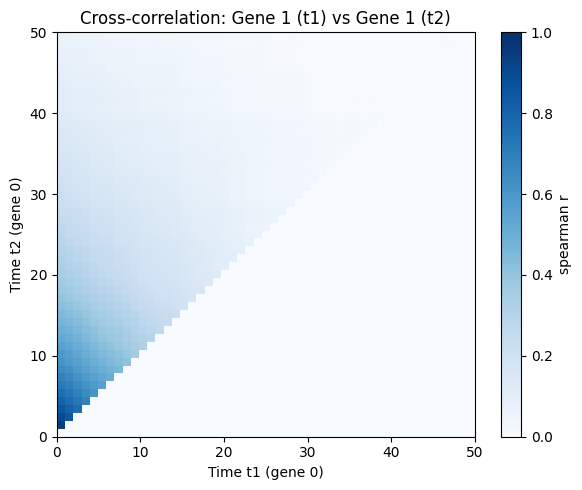

0 1


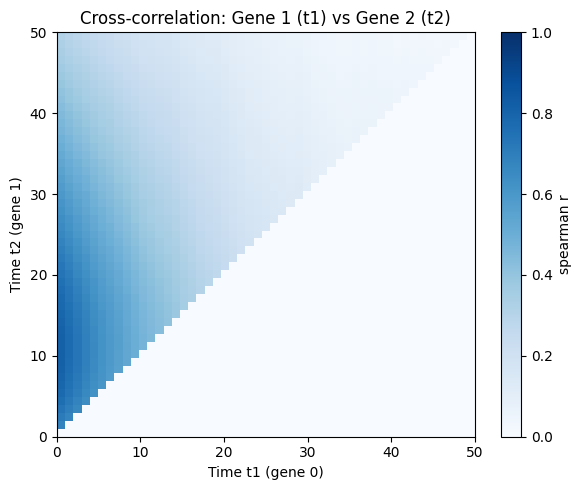

0 2


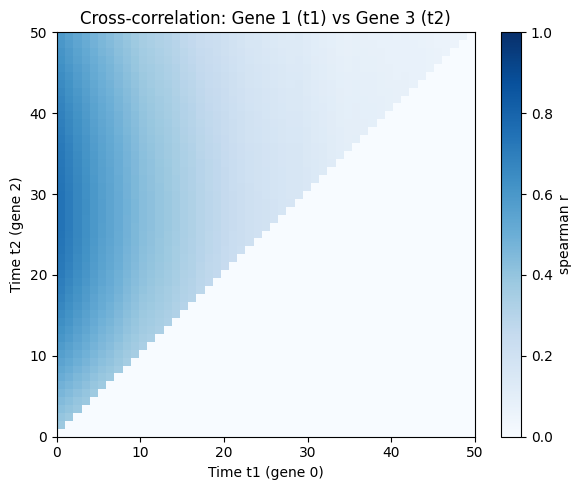

1 0


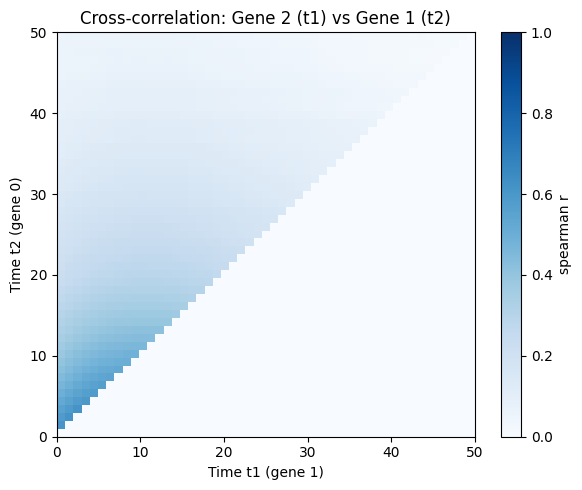

1 1


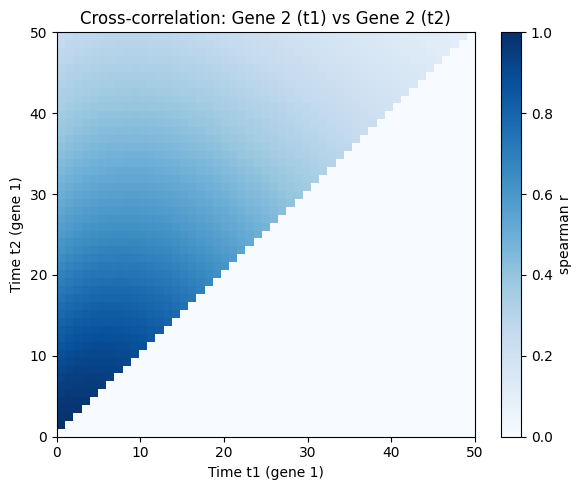

1 2


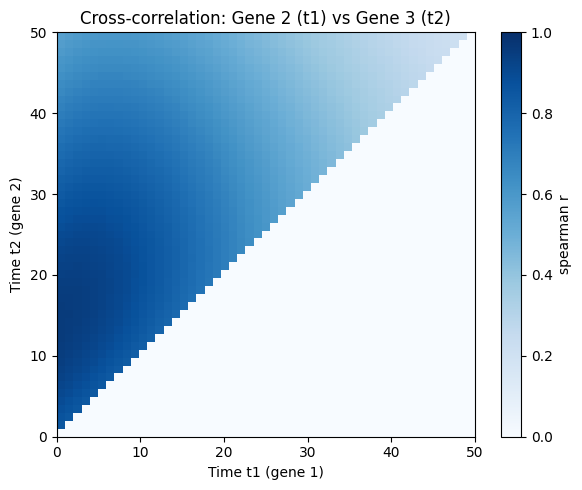

2 0


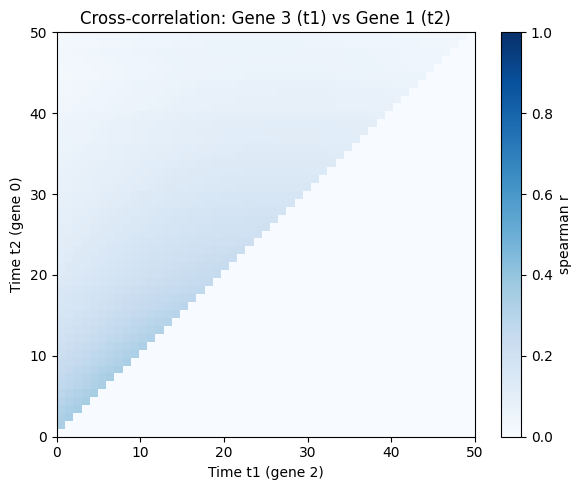

2 1


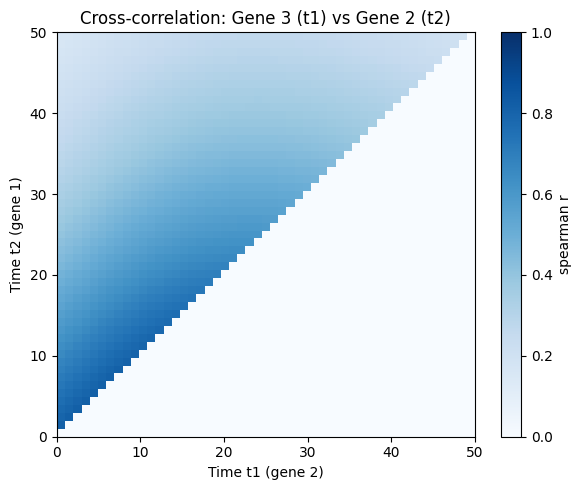

2 2


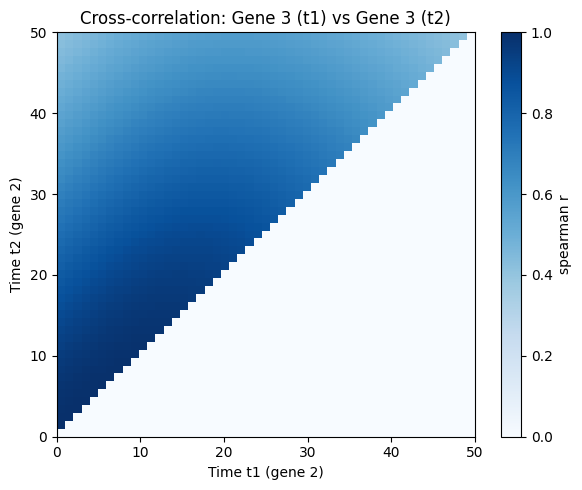

In [6]:
from scipy.stats import pearsonr, spearmanr

def compute_cross_correlation_matrix(x1_all, x2_all, gene_i, gene_j, dt):
    n_cells, n_time, _ = x1_all.shape
    time_points = np.arange(0, 50/dt + 1, 1/dt)
    n_t = len(time_points)
    corr_matrix = np.zeros((n_t, n_t))

    for idx_t1, t1 in enumerate(range(n_t)):
        vec_i = x1_all[:, t1, gene_i]
        for idx_t2, t2 in enumerate(range(n_t)):
            if t2 > t1:
                vec_j = x2_all[:, t2, gene_j]
                r, _ = spearmanr(vec_i, vec_j)
                corr_matrix[idx_t1, idx_t2] = r

    return time_points, corr_matrix

def plot_cross_corr_heatmap(corr_matrix, time_points, g1, g2):
    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr_matrix.T, cmap="Blues", vmin=0, vmax=1, origin="lower",
           extent=[time_points[0], time_points[-1], time_points[0], time_points[-1]],
           aspect="auto")
    plt.xlabel(f"Time t1 (gene {g1})")
    plt.ylabel(f"Time t2 (gene {g2})")

    plt.colorbar(im, label="spearman r")
    plt.title(f"Cross-correlation: Gene {g1+1} (t1) vs Gene {g2+1} (t2)")
    plt.tight_layout()
    plt.show()

from itertools import product
gene_pairs = list(product(range(n_genes), repeat=2))

for g1, g2 in gene_pairs:
    print(g1,g2)
    t_array, cross_corr = compute_cross_correlation_matrix(x1_all, x2_all, g1, g2, dt)
    plot_cross_corr_heatmap(cross_corr, t_array*dt, g1, g2)

# Figure S1

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


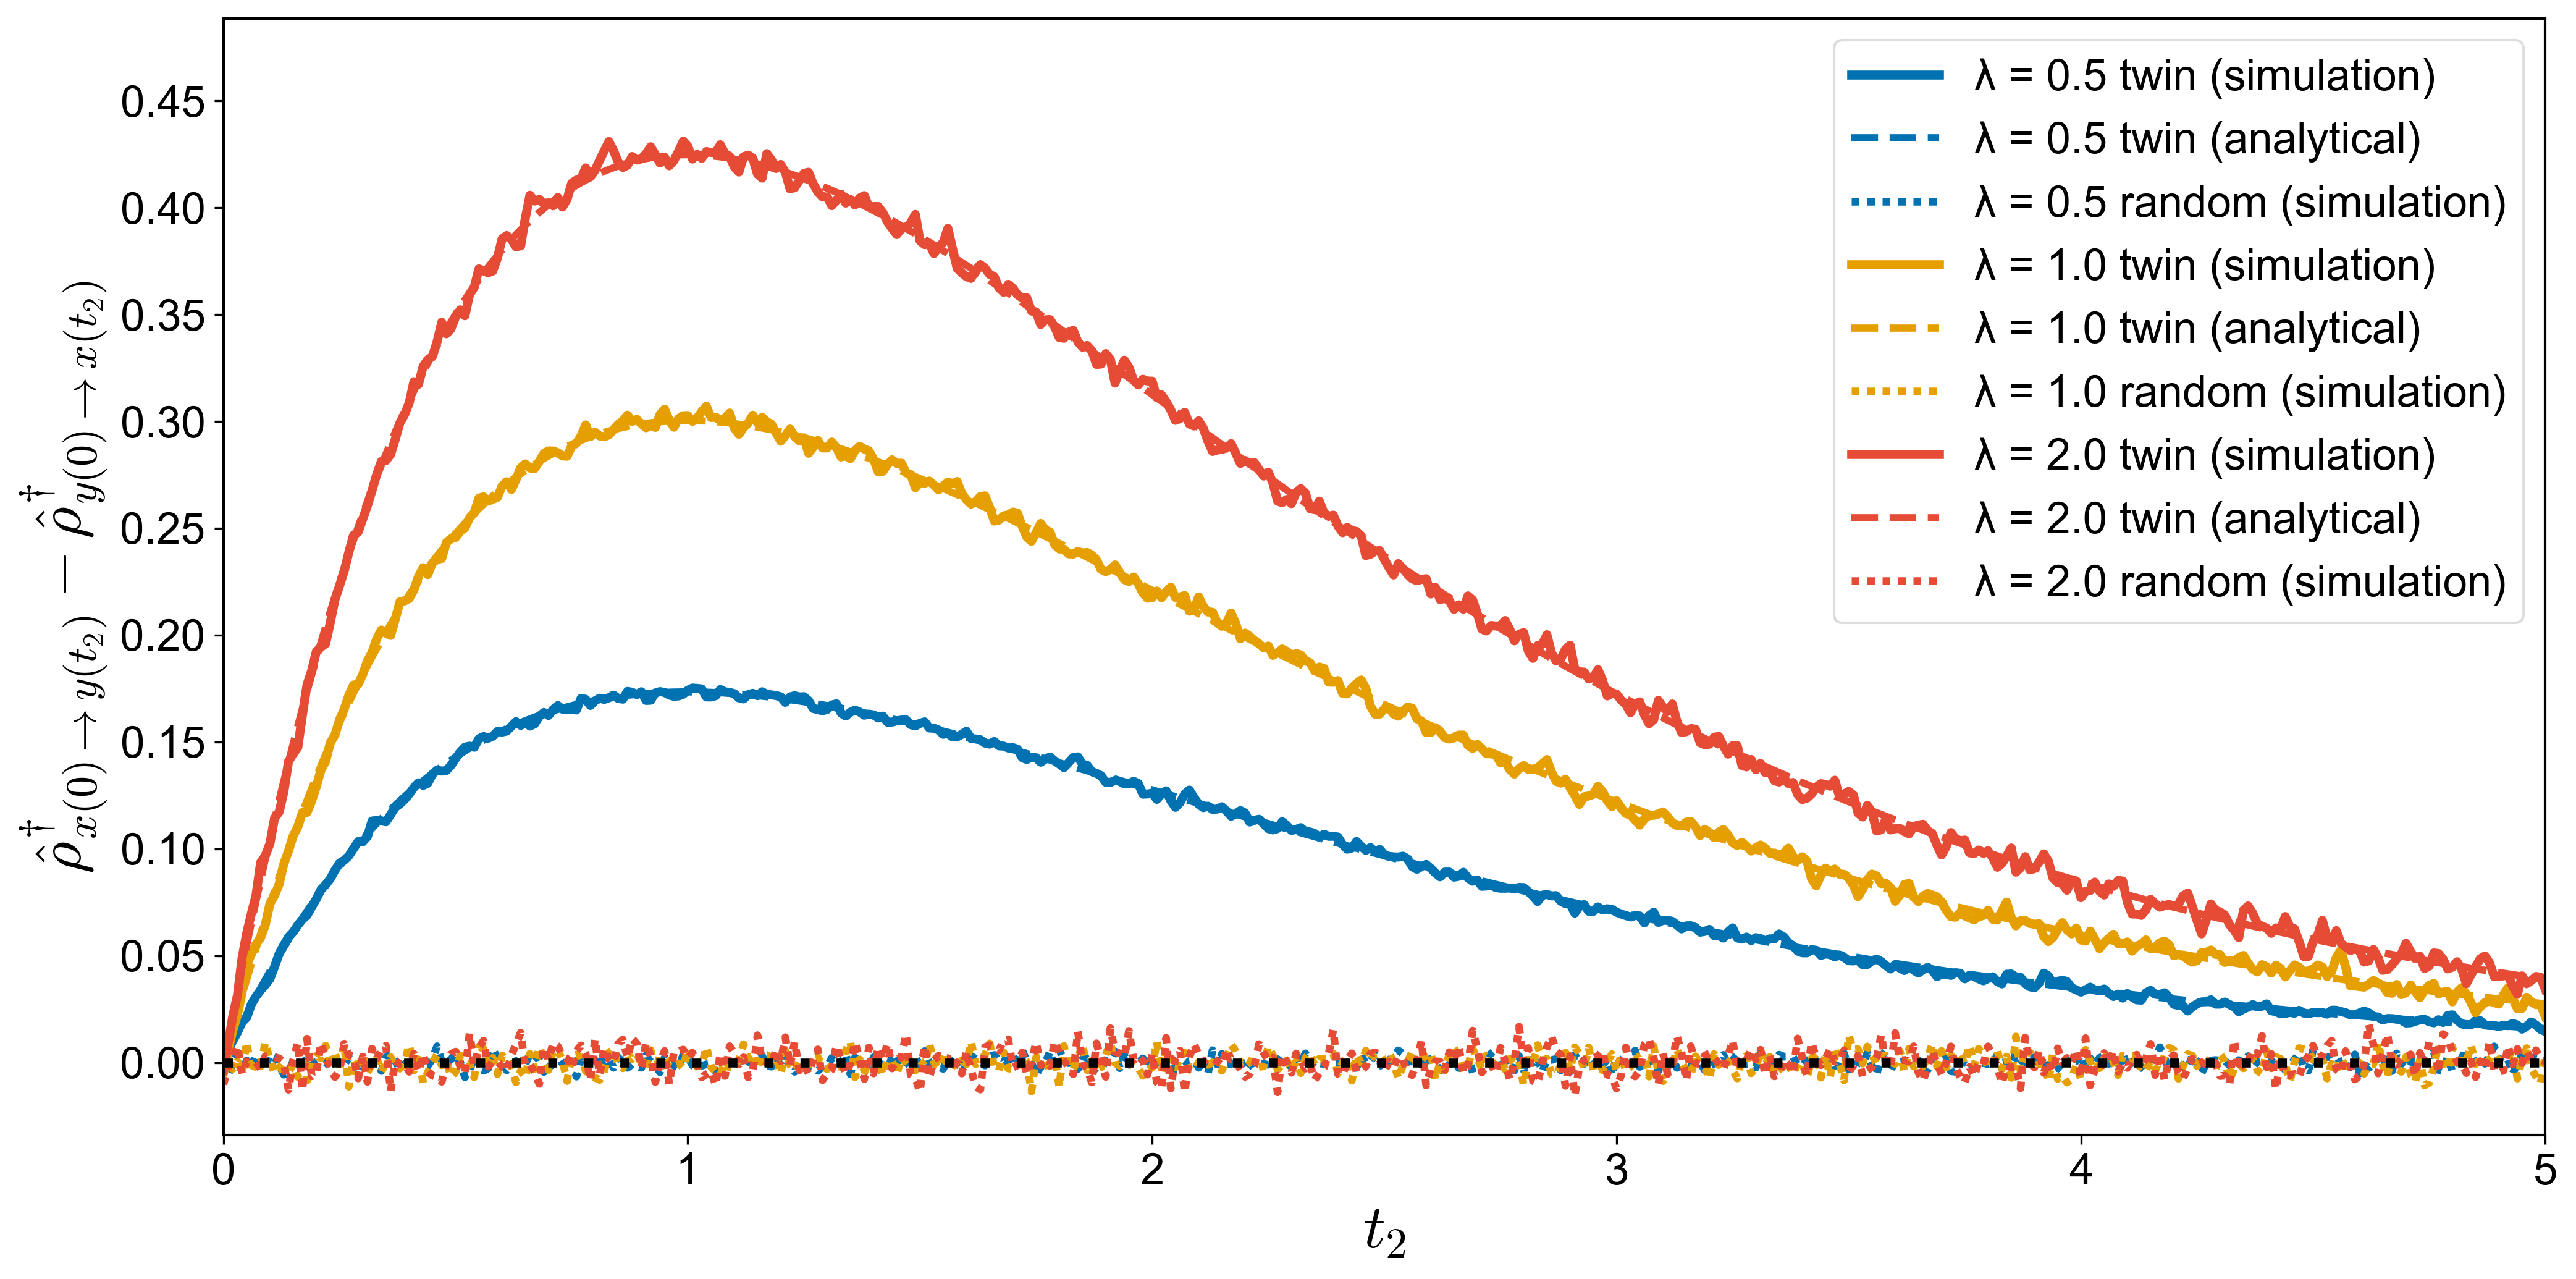

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ---------- Register fonts (Arial + CM ttf you copied) ----------
font_files = [
    "/home/gzu5140/Arial.ttf",
    "/home/gzu5140/Arial Bold.ttf",
    "/home/gzu5140/Arial Italic.ttf",
    "/home/gzu5140/Arial Bold Italic.ttf",
    "/home/gzu5140/cmmi10.ttf",
    "/home/gzu5140/cmr10.ttf",
    "/home/gzu5140/cmsy10.ttf",
]

for fp in font_files:
    try:
        fm.fontManager.addfont(fp)
        # print(f"✔ Registered font: {fp}")
    except Exception:
        pass

# ---------- Aesthetics: LaTeX-like text, keep sizes as you set ----------
plt.rcParams['pdf.fonttype'] = 42        # keep text as text in PDF
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = "none"

plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"

# Use Computer Modern math fonts you registered above
plt.rcParams['mathtext.fontset'] = "cm"

# Keep your axis line style
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 2.0

# ---------- Parameters ----------
D = 1.25   # diffusion/variance scale (Q = 2 D I)

# ---------- Model (same as yours) ----------
def expm_negA_t(lmbd, t):
    e = np.exp(-t)
    return e * np.array([[1.0, 0.0],
                         [lmbd * t, 1.0]])

def steady_cov(lmbd, D=1.0):
    """
    Steady-state covariance Σ_ss solving AΣ+ΣA^T=2D I.
    Base (D=1) is [[1, λ/2],[λ/2, 1+λ^2/2]], then scale by D.
    """
    lam = lmbd
    s11 = 1.0
    s12 = (lam * s11) / 2.0
    s22 = 1.0 + lam * s12          # = 1 + λ^2/2
    Sig = np.array([[s11, s12],
                    [s12, s22]], dtype=float)
    return D * Sig

# --- Pearson analytic curve (independent of D) ---
def delta_analytic_pearson(lam, taus):
    return (lam * taus * np.exp(-taus)) / np.sqrt(1.0 + 0.5 * lam * lam)

# --- Simulation (same structure), Pearson normalization (use Σ with D) ---
def delta_twin_random(lmbd, taus, N=10000, seed=17, D=1.0):
    """
    Returns:
      d_twin_noisy:  Δρ_Pearson(t) for TWIN (with jitter)
      d_rand_noisy:  Δρ_Pearson(t) for RANDOM (with jitter)
      d_twin_clean:  Δρ_Pearson(t) for TWIN (clean)
    """
    rng = np.random.default_rng(seed)
    Sigma = steady_cov(lmbd, D=D)
    L = np.linalg.cholesky(Sigma)

    # Twins share the same c0; Random uses independent c0A, c0B
    c0  = L @ rng.standard_normal((2, N))
    c0A = L @ rng.standard_normal((2, N))
    c0B = L @ rng.standard_normal((2, N))

    d_twin = np.empty_like(taus, dtype=float)
    d_rand = np.empty_like(taus, dtype=float)

    lam = lmbd
    # Pearson denominator is sqrt(Var[x0]*Var[y2]) = sqrt(Σ11 * Σ22) = D * sqrt(1 + λ^2/2)
    denom = D * np.sqrt(1.0 + 0.5 * lam * lam)

    for i, t in enumerate(taus):
        M = expm_negA_t(lam, t)

        # covariance-difference (shared c0)
        xA0, yA0 = c0[0],            c0[1]
        xB_t, yB_t = (M @ c0)[0],    (M @ c0)[1]
        covdiff_twin = np.mean(xA0 * yB_t - yA0 * xB_t)

        # random baseline (independent initial draws)
        xA0r, yA0r = c0A[0],             c0A[1]
        xB_tr, yB_tr = (M @ c0B)[0],     (M @ c0B)[1]
        covdiff_rand = np.mean(xA0r * yB_tr - yA0r * xB_tr)

        d_twin[i] = covdiff_twin / denom
        d_rand[i] = covdiff_rand / denom

    
    peak = float(np.max(delta_analytic_pearson(lmbd, taus)))
    rng2 = np.random.default_rng(seed + 1)
    amp = 0.015 * peak
    jitter = rng2.normal(0, amp, size=len(taus))
    jitter = 0.6*jitter + 0.25*np.roll(jitter, 1) + 0.15*np.roll(jitter, -1)
    d_twin_noisy = d_twin + jitter

    rng3 = np.random.default_rng(seed + 2)
    d_rand_noisy = d_rand + rng3.normal(0, 0.015 * peak, size=len(taus))

    return d_twin_noisy, d_rand_noisy, d_twin

def moving_average(x, w):
    kernel = np.ones(w)/w
    return np.convolve(x, kernel, mode='same')

# ---------- Plot (same style/labels) ----------
taus = np.linspace(0.0, 5.0, 501)
lambdas = [0.5, 1.0, 2.0]
colors = {0.5: '#0072B2', 1.0: '#E69F00', 2.0: '#E64B35'}

fig, ax = plt.subplots(figsize=(14, 7))

ax.set_xlabel(r"$t_2$", fontsize=24)
ax.set_ylabel(r"$\hat{\rho}^{\dagger}_{x(0)\to y(t_2)} - \hat{\rho}^{\dagger}_{y(0)\to x(t_2)}$", fontsize=24)
ax.set_xlim(0, 5)
ax.grid(False)

# auto y-limit from analytic peak (Pearson curve does not depend on D)
d_an_all = {lam: delta_analytic_pearson(lam, taus) for lam in lambdas}
ymax = float(max(np.max(v) for v in d_an_all.values()))
ax.set_ylim(-0.02, ymax * 1.15)
tick_top = np.ceil(ymax * 1.10 * 20) / 20.0  # 0.05 step rounding
ax.set_yticks(np.arange(0.0, tick_top + 1e-6, 0.05))

# spines & baseline
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')
ax.axhline(0, color="black", linewidth=3.5, linestyle=(0, (1, 3)), zorder=5)

lower_pad = 0.08 * ymax
ax.set_ylim(-lower_pad, ymax * 1.15)

handles, labels = [], []
lw_sim, lw_an, lw_rand = 3.5, 2.8, 3.0

for lam in lambdas:
    d_twin_noisy, d_rand_noisy, d_twin_clean = delta_twin_random(
        lam, taus, N=800000, seed=100 + int(lam*10), D=D
    )
    d_an = d_an_all[lam]

    h1, = ax.plot(taus, d_twin_noisy, color=colors[lam], linestyle='-', linewidth=lw_sim)
    handles.append(h1); labels.append(f"λ = {lam} twin (simulation)")

    h2, = ax.plot(taus, d_an, color=colors[lam], linestyle='--', linewidth=lw_an)
    handles.append(h2); labels.append(f"λ = {lam} twin (analytical)")

    h3, = ax.plot(taus, d_rand_noisy, color=colors[lam], linestyle=(0, (1, 1)), linewidth=lw_rand)
    handles.append(h3); labels.append(f"λ = {lam} random (simulation)")

leg = ax.legend(handles, labels, loc="upper right", framealpha=1.0, fontsize=17)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("#DDDDDD")

plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.tight_layout()
plt.savefig("Boxed_Asymmetric_Cross_Correlation_Pearson.pdf", dpi=400)
plt.show()


# Figure S2

✔ Registered font: /home/gzu5140/Arial.ttf
✔ Registered font: /home/gzu5140/Arial Bold.ttf
✔ Registered font: /home/gzu5140/Arial Italic.ttf
✔ Registered font: /home/gzu5140/cmmi10.ttf
✔ Registered font: /home/gzu5140/cmr10.ttf
✔ Registered font: /home/gzu5140/cmsy10.ttf
✔ Loaded cached simulation results from:
   /home/gzu5140/Keerthana_b1042/GRNanalysis/simulation_data/three_gene/twin_results_3motifs_lambda0p8.npz


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


📊 Figure saved to:
  /home/gzu5140/Keerthana_b1042/GRNanalysis/simulation_data/three_gene/Cross_Correlation_Analytics_lambda0p8.pdf


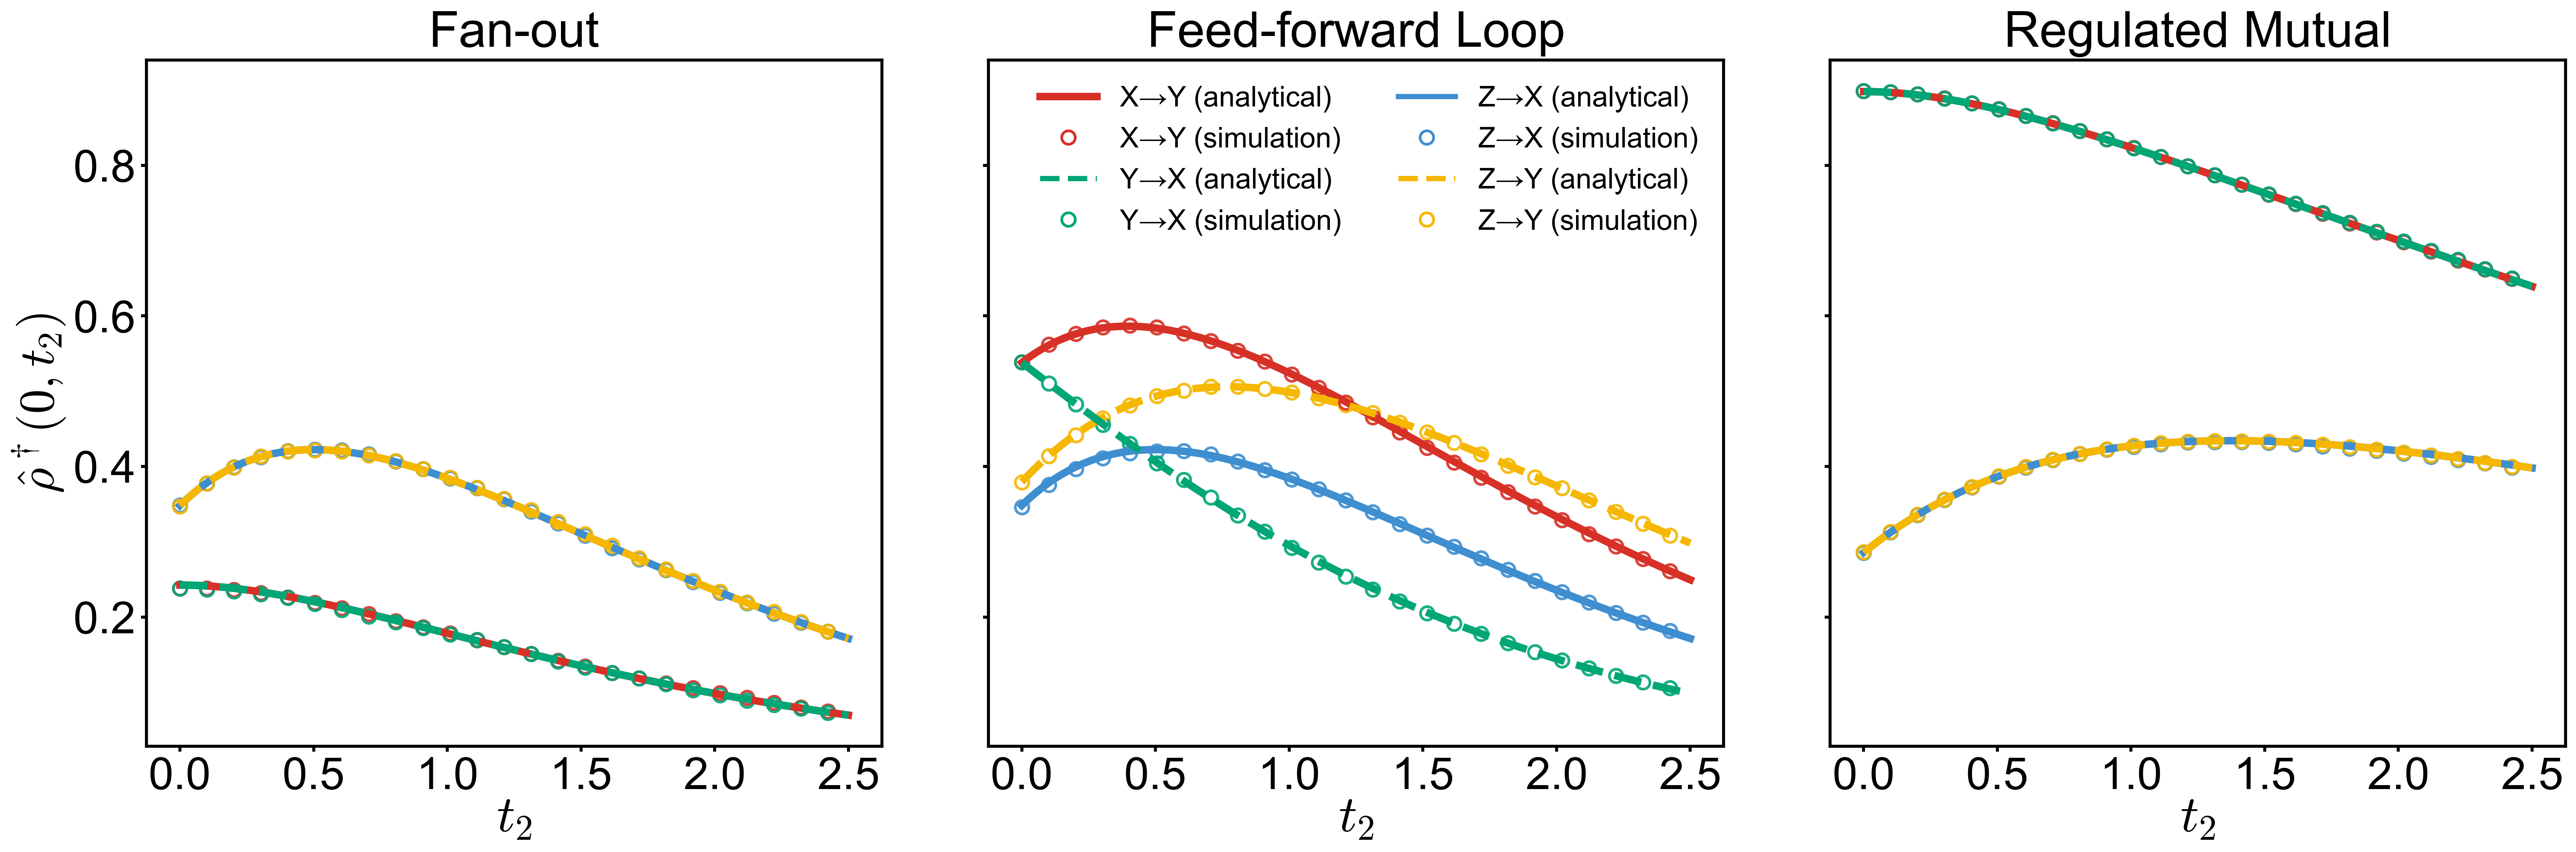

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from numpy.random import default_rng
from scipy.stats import pearsonr
from matplotlib.ticker import MultipleLocator
from scipy.linalg import solve_continuous_lyapunov, cholesky
import matplotlib.font_manager as fm
import os

# ============================================================
# Font registration + global rcParams (LaTeX-like style)
# ============================================================

# Register Arial + CM math fonts from your home directory
font_files = [
    "/home/gzu5140/Arial.ttf",
    "/home/gzu5140/Arial Bold.ttf",
    "/home/gzu5140/Arial Italic.ttf",
    "/home/gzu5140/cmmi10.ttf",
    "/home/gzu5140/cmr10.ttf",
    "/home/gzu5140/cmsy10.ttf",
]

for fp in font_files:
    try:
        fm.fontManager.addfont(fp)
        print(f"✔ Registered font: {fp}")
    except Exception as e:
        print(f"⚠️  Could not register font {fp}: {e}")

# Global plotting style
# Global Matplotlib style (match second script)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = "none"

plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family']     = "sans-serif"
plt.rcParams['mathtext.fontset'] = "cm"

plt.rcParams['axes.labelsize']  = 33
plt.rcParams['axes.titlesize']  = 33
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 30

plt.rcParams['figure.dpi'] = 400
plt.rcParams['axes.grid']  = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# A bit of your usual styling
plt.rcParams.update({
    "figure.dpi": 300,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ============================================================
# Paths
# ============================================================
save_dir = "/home/gzu5140/Keerthana_b1042/GRNanalysis/simulation_data/three_gene"
os.makedirs(save_dir, exist_ok=True)
npz_path = os.path.join(save_dir, "twin_results_3motifs_lambda0p8.npz")
fig_path = os.path.join(save_dir, "Cross_Correlation_Analytics_lambda0p8.pdf")

# ============================================================
# Parameters
# ============================================================
D = 1.25
dt = 1e-3
N_PAIRS = 300_000
t2_vals = np.linspace(0.0, 2.5, 100)
rng = default_rng(0)

# 4 directed pairs we care about
pairs = [(2, 0), (2, 1), (0, 1), (1, 0)]     # Z→X, Z→Y, X→Y, Y→X
labels = ["Z→X", "Z→Y", "X→Y", "Y→X"]

# Color-blind-friendly palette
colors = ["#3E8ED0", "#F5B700", "#D73027", "#00A676"]
color_map = dict(zip(labels, colors))

motif_titles = ["Fan-out", "Feed-forward Loop", "Regulated Mutual"]
LAMBDA = 0.8   # all motifs use this

# ============================================================
# Helpers
# ============================================================
def corr_pearson(a, b):
    return pearsonr(a, b)[0]

def steady_cov(A, D):
    """Solve A Σ + Σ A^T = 2 D I."""
    Q = 2.0 * D * np.eye(A.shape[0])
    S = solve_continuous_lyapunov(A, Q)
    return 0.5 * (S + S.T)

def simulate_twins_samples(A, D, dt, t2_vals, N, rng):
    """
    Memory-efficient TwIN simulation:
      - Draw shared x0 from steady state.
      - Evolve twin-2 with independent noise.
      - Return x0 and twin-2 at each t2.
    """
    d = A.shape[0]
    Sigma = steady_cov(A, D)
    L = cholesky(Sigma, lower=True)

    # shared initial conditions
    z0 = rng.standard_normal(size=(d, N))
    x0 = (L @ z0).T  # (N, d)

    # map t2 to time steps
    step_idx = np.array([int(round(t/dt)) for t in t2_vals], dtype=int)
    max_step = int(step_idx.max())

    xt = np.zeros((len(t2_vals), N, d))
    x = x0.copy()
    s = np.sqrt(2.0 * D * dt)
    AT = A.T

    # handle t2 = 0
    k = 0
    if step_idx[0] == 0:
        xt[0, :, :] = x
        k = 1

    for step in range(1, max_step + 1):
        eta = rng.standard_normal(size=(N, d))
        drift = -(x @ AT)
        x = x + drift * dt + s * eta

        while k < len(step_idx) and step_idx[k] == step:
            xt[k, :, :] = x
            k += 1
        if k >= len(step_idx):
            break

    return x0, xt

# ============================================================
# Motif A matrices
# ============================================================
def A_fanout(l):
    # Z → X, Z → Y (same parent)
    return np.array([
        [1.0, 0.0, -l],
        [0.0, 1.0, -l],
        [0.0, 0.0,  1.0]
    ])

def A_feedforward(l):
    # Z → X, Z → Y, X → Y
    return np.array([
        [1.0, 0.0, -l],
        [-l,  1.0, -l],
        [0.0, 0.0,  1.0]
    ])

def A_mutual(l):
    # regulated mutual + common Z input
    return np.array([
        [1.0, -l,  -l],
        [-l,  1.0, -l],
        [0.0, 0.0,  1.0]
    ])

# ============================================================
# Analytical formulas: normalized TwIN ρ̂†
# ============================================================
def rho_S34(t, l):
    # Fan-out (Eq. S34)
    d = 2.0 + l**2
    f = np.exp(-t)
    m = np.zeros((3, 3))
    m[0, 0] = (2.0 + l**2 + l**2 * t) / d
    m[1, 1] = m[0, 0]
    m[0, 1] = l**2 * (1.0 + t) / d
    m[1, 0] = m[0, 1]
    m[0, 2] = l / np.sqrt(2.0 * d)
    m[1, 2] = l / np.sqrt(2.0 * d)
    m[2, 0] = l * (1.0 + 2.0 * t) / np.sqrt(2.0 * d)
    m[2, 1] = m[2, 0]
    m[2, 2] = 1.0
    return f * m

def rho_S35_feed(t, l):
    # Feed-forward loop (S35) – normalized
    e = np.exp(-t)
    L2 = l**2
    d1 = 2.0 + L2
    d2 = 8.0 + L2 * (8.0 + 3.0 * l * (2.0 + l))
    r = np.zeros((3, 3))
    r[0, 0] = (2.0 + L2 + L2 * t) / d1
    r[0, 1] = l * (
        4.0 + l*(4.0 + 3.0*l)
        + 4.0*(2.0 + l + L2)*t
        + 2.0*L2*t**2
    ) / (2.0*np.sqrt(d1*d2))
    r[0, 2] = l / np.sqrt(2.0*d1)
    r[1, 0] = l * (
        4.0 + l*(4.0 + 3.0*l)
        + 2.0*l*(2.0 + l)*t
    ) / (2.0*np.sqrt(d1*d2))
    r[1, 1] = (
        8.0
        + L2*(8.0 + 3.0*l*(2.0 + l))
        + L2*t*(8.0 + 3.0*l*(2.0 + l) + l*(2.0 + l)*t)
    ) / d2
    r[1, 2] = l * (2.0 + l) / np.sqrt(2.0*d2)
    r[2, 0] = l * (1.0 + 2.0*t) / np.sqrt(2.0*d1)
    r[2, 1] = l * (2.0 + l + 2.0*t*(2.0 + l + l*t)) / np.sqrt(2.0*d2)
    r[2, 2] = 1.0
    return e * r

def rho_S35_mutual(t, l):
    # Regulated mutual motif – normalized
    den = 2.0 + l*(-1.0 + l + l**2)
    root = np.sqrt(den / ((-2.0 + l)*(-1.0 + l)*(1.0 + l)))
    e = np.exp(-t)
    ch = np.cosh(l*t)
    sh = np.sinh(l*t)
    rxx = e * ((2.0 + l**2)*ch + l*(-1.0 + l**2 + 3.0*sh)) / den
    rxy = e * (-l + l**3 + 3.0*l*ch + (2.0 + l**2)*sh) / den
    rxz = -e * l / ((-2.0 + l) * root)
    rzx = -e * (-2.0 + 2.0*np.exp(l*t) + l) / ((-2.0 + l) * root)
    rzz = e
    return np.array([[rxx, rxy, rxz],
                     [rxy, rxx, rxz],
                     [rzx, rzx, rzz]])

motifs = [
    ("Fan Out",          A_fanout,      rho_S34,        LAMBDA),
    ("Feedforward Loop", A_feedforward, rho_S35_feed,   LAMBDA),
    ("Regulated Mutual", A_mutual,      rho_S35_mutual, LAMBDA),
]

# ============================================================
# Run simulations & compute rho, then save
# ============================================================
# ============================================================
# Load precomputed simulation results
# ============================================================
data = np.load(npz_path)
t2_vals = data["t2_vals"]
rho_emp = data["rho_emp"]
rho_th  = data["rho_th"]

print("✔ Loaded cached simulation results from:")
print("  ", npz_path)

# print(f"⏱ Running TwIN simulations for λ = {LAMBDA} ...")
# M = len(motifs)
# P = len(pairs)
# T = len(t2_vals)

# rho_emp = np.zeros((M, P, T), dtype=np.float32)
# rho_th  = np.zeros((M, P, T), dtype=np.float32)

# for m_idx, (title, A_fn, rho_fn, lam) in enumerate(motifs):
#     print(f"  - {title}, λ={lam}")
#     A = A_fn(lam)
#     x0, xt = simulate_twins_samples(A, D, dt, t2_vals, N_PAIRS, rng)

#     for p_idx, ((i, j), lab) in enumerate(zip(pairs, labels)):
#         # analytic
#         rho_th[m_idx, p_idx, :] = np.array(
#             [rho_fn(t, lam)[i, j] for t in t2_vals],
#             dtype=np.float32
#         )
#         # empirical TwIN correlation
#         rho_emp[m_idx, p_idx, :] = np.array(
#             [corr_pearson(x0[:, i], xt[k, :, j]) for k in range(T)],
#             dtype=np.float32
#         )

# np.savez_compressed(
#     npz_path,
#     t2_vals=t2_vals.astype(np.float32),
#     rho_emp=rho_emp,
#     rho_th=rho_th,
# )
# print(f"✅ Saved results to:\n  {npz_path}")

# ============================================================
# Plot three-panel figure
# ============================================================
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(24, 8))
sample_idx = np.arange(0, len(t2_vals), 4)
fig.subplots_adjust(
    wspace=0.15   # <--- decrease horizontal space between panels
)

for m_idx, title in enumerate(motif_titles):
    ax = axes[m_idx]

    for p_idx, ((i, j), lab, col) in enumerate(zip(pairs, labels, colors)):
        th = rho_th[m_idx, p_idx, :]
        emp = rho_emp[m_idx, p_idx, :]

        # dashed for Y→X, Z→Y
        if lab in ["Y→X", "Z→Y"]:
            ls = '--'
            z_line = 5
        else:
            ls = '-'
            z_line = 4

        # analytic line
        ax.plot(
            t2_vals,
            th,
            ls,
            lw=5,
            color=col,
            alpha=1.0,
            zorder=z_line,
        )

        # hollow dots for simulation
        ax.plot(
            t2_vals[sample_idx],
            emp[sample_idx],
            'o',
            ms=9,
            mfc='none',
            mec=col,
            mew=1.8,
            alpha=0.9,
            zorder=3,
        )

    ax.set_title(title, pad=9)
    ax.set_xlabel(r"$t_2$", fontsize=34, labelpad=-2)
    ax.tick_params(width=2)

    ax.xaxis.set_major_locator(MultipleLocator(0.5))   # default was ~0.5, now doubled


    # boxed look for all spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

axes[0].set_ylabel(r"$\hat{\rho}^\dagger(0,t_2)$")

# Legend
legend_elements = [
    Line2D([], [], color=color_map["X→Y"], lw=5, ls='-',
           label="X→Y (analytical)"),
    Line2D([], [], marker='o', ls='None', mfc='none',
           mec=color_map["X→Y"], mew=1.8, ms=9,
           label="X→Y (simulation)"),
    Line2D([], [], color=color_map["Y→X"], lw=3.5, ls='--',
           label="Y→X (analytical)"),
    Line2D([], [], marker='o', ls='None', mfc='none',
           mec=color_map["Y→X"], mew=1.8, ms=9,
           label="Y→X (simulation)"),
    Line2D([], [], color=color_map["Z→X"], lw=3.5, ls='-',
           label="Z→X (analytical)"),
    Line2D([], [], marker='o', ls='None', mfc='none',
           mec=color_map["Z→X"], mew=1.8, ms=9,
           label="Z→X (simulation)"),
    Line2D([], [], color=color_map["Z→Y"], lw=3.5, ls='--',
           label="Z→Y (analytical)"),
    Line2D([], [], marker='o', ls='None', mfc='none',
           mec=color_map["Z→Y"], mew=1.8, ms=9,
           label="Z→Y (simulation)"),
]

axes[1].legend(
    handles=legend_elements,
    fontsize=19,
    ncol=2,
    frameon=False,
    loc="upper right",
)

plt.tight_layout()

# Remove clipping so Illustrator edits are easier
for artist in plt.gcf().findobj():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)

# Save as vector PDF, transparent background
plt.savefig(
    fig_path,
    format="pdf",
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none",
    transparent=True,
    pad_inches=0.02,
)
print(f"📊 Figure saved to:\n  {fig_path}")

plt.show()
